# Direct stellar metallicity: Gallazzi DR4 and FIREFLY DR16

This notebook continues—not replaces—the historical [index-level feasibility notebook](metallicity_scoping.ipynb) and its [immutable report](REPORT.md). It carries the same chosen spectra and parent rows into direct stellar-metallicity catalogues, analyses satellites and BGGs separately, and takes Control4C as the primary compact-core analogue.

The calculations live in `zstar_analysis.py` so that the notebook and command-line run share one implementation. Set `REFRESH=True` below to regenerate all small analysis products from the cached catalogue matches. Catalogue acquisition itself is isolated in the idempotent `zstar_fetch.py`.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display
import zstar_analysis as za

HERE = Path.cwd()
if not (HERE / "zstar_analysis.py").exists():
    raise RuntimeError("Run this notebook from exploration/metallicity")
REFRESH = False
required = HERE / "outputs" / "zstar" / "zstar_contrasts.csv"
if REFRESH or not required.exists():
    za.main()
print("Analysis products:", required.parent)

Analysis products: /Users/matt/Astrophysics/CG_Gals/exploration/metallicity/outputs/zstar


## 1. Acquisition integrity and conventions

Plate–MJD–fibre is the authoritative spectrum key. The FIREFLY `SPECOBJID` is not used. Gallazzi's absolute `log10(Z)` values are converted using `Z_sun=0.02`; FIREFLY's linear `Z/Z_sun` values are converted with `log10`. Sentinel values are removed before either transformation.

In [2]:
manifest = json.loads((HERE / "work/catalogues/catalogue_manifest.json").read_text())
run2d = manifest["firefly"]["returned_run2d"]
assert sum(run2d.values()) == manifest["firefly"]["matched_unique_pmf"]
assert manifest["sdss_aux"]["matched_unique_objid"] == 3857
display(pd.DataFrame({
    "check": ["Gallazzi matched PMF", "FIREFLY matched PMF", "FIREFLY RUN2D count sum", "SDSS photometry objid"],
    "N": [manifest["gallazzi"]["matched_unique_pmf"], manifest["firefly"]["matched_unique_pmf"], sum(run2d.values()), manifest["sdss_aux"]["matched_unique_objid"]],
}))
print("RUN2D:", run2d)

,check,N
0,Gallazzi matched PMF,1665
1,FIREFLY matched PMF,3835
2,FIREFLY RUN2D count sum,3835
3,SDSS photometry objid,3857


RUN2D: {'26': 3645, 'v5_13_0': 190}


## 2. Coverage and selection

`usable` means Gallazzi valid plus S/N≥20, reflecting that catalogue's published reliability study. FIREFLY uses valid ordered posteriors plus a galaxy classification and valid no-QSO redshift; S/N cuts are sensitivities, not the primary selection.

,catalogue,sample,role,parent_n,match_n,valid_n,usable_n,retained_fraction,median_z,median_logmstar,median_SN,median_logz_unc_dex
0,Gallazzi DR4,CG4,BGG,62,30,27,27,43.5%,0.0367,11.08,41.0,0.069
1,Gallazzi DR4,CG4,Satellite,186,99,76,63,33.9%,0.0370,10.37,28.8,0.106
2,Gallazzi DR4,RG4,BGG,56,31,30,30,53.6%,0.0389,10.99,38.4,0.077
3,Gallazzi DR4,RG4,Satellite,168,93,73,43,25.6%,0.0373,10.43,26.4,0.128
4,Gallazzi DR4,Control4B,BGG,698,296,283,282,40.4%,0.0342,11.09,41.5,0.059
5,Gallazzi DR4,Control4B,Satellite,2094,904,799,637,30.4%,0.0334,10.60,34.0,0.096
6,Gallazzi DR4,Control4C,BGG,703,297,284,283,40.3%,0.0343,11.09,41.5,0.059
7,Gallazzi DR4,Control4C,Satellite,2109,907,774,553,26.2%,0.0334,10.40,30.2,0.110
8,FIREFLY DR16 MILES light-weighted,CG4,BGG,62,61,60,60,96.8%,0.0365,11.12,41.1,0.035
9,FIREFLY DR16 MILES light-weighted,CG4,Satellite,186,185,180,180,96.8%,0.0366,10.18,25.8,0.069


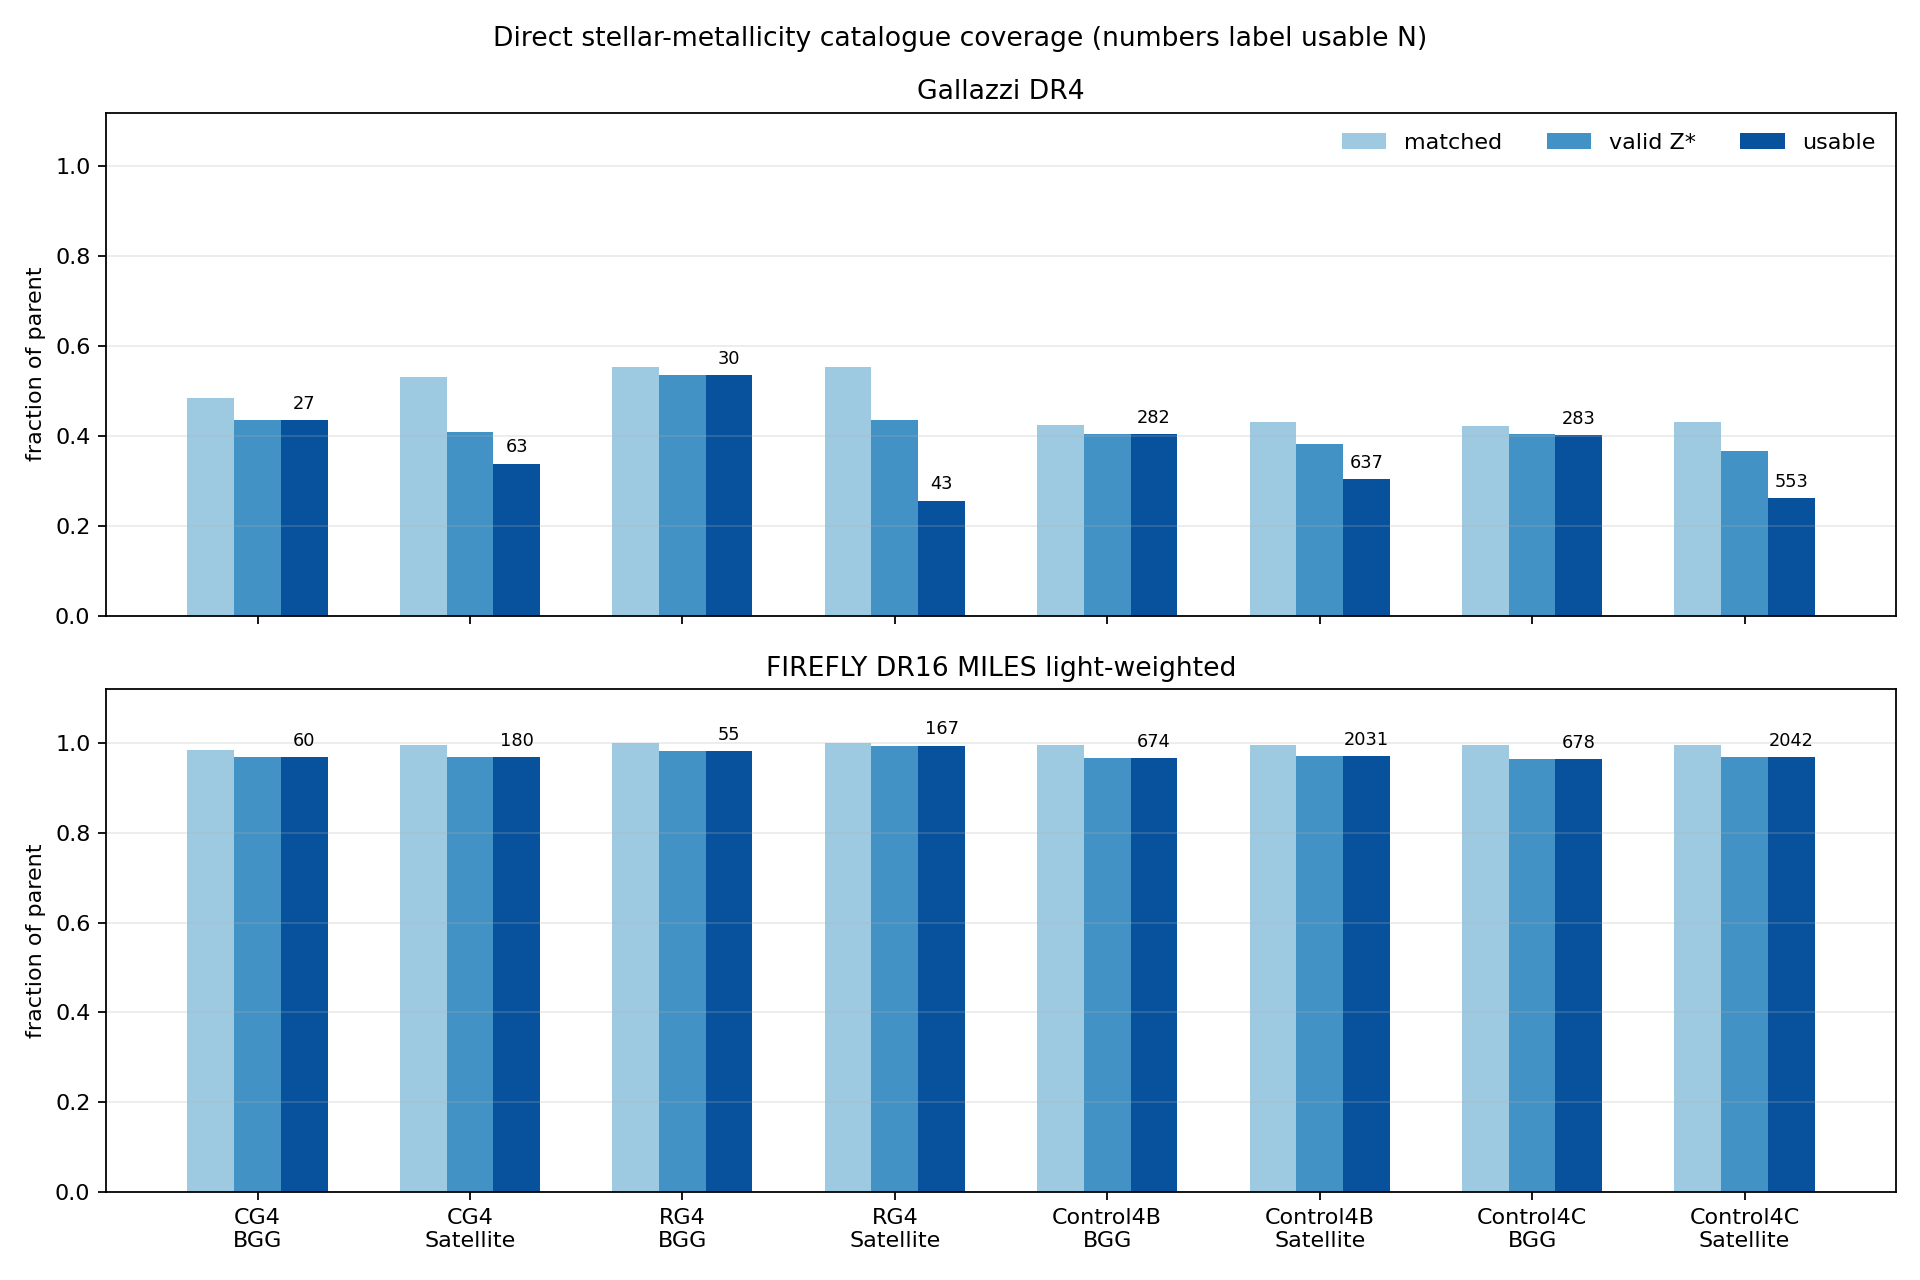

In [3]:
coverage = pd.read_csv(HERE / "outputs/zstar/coverage.csv")
display(coverage.style.format({"retained_fraction": "{:.1%}", "median_z": "{:.4f}", "median_logmstar": "{:.2f}", "median_SN": "{:.1f}", "median_logz_unc_dex": "{:.3f}"}))
display(Image(filename=str(HERE / "figures/zstar/coverage.png")))

,catalogue,variable,usable_minus_not_smd,usable_median,not_usable_median,abs_smd
3,Gallazzi DR4,SN,0.610065,35.086800,28.367750,0.610065
0,Gallazzi DR4,lgm,0.501899,10.665630,10.369575,0.501899
2,Gallazzi DR4,r_petro_dered,-0.451647,14.644903,15.201694,0.451647
8,FIREFLY DR16 MILES light-weighted,r_petro_dered,0.262345,15.017799,14.695251,0.262345
11,FIREFLY DR16 MILES light-weighted,R50_kpc,-0.167351,3.607478,3.814899,0.167351
4,Gallazzi DR4,fibre_light_fraction,0.151724,0.157715,0.138989,0.151724
1,Gallazzi DR4,z,-0.147660,0.033799,0.035679,0.147660
6,FIREFLY DR16 MILES light-weighted,lgm,0.131300,10.481890,10.571360,0.131300
10,FIREFLY DR16 MILES light-weighted,fibre_light_fraction,0.122072,0.144934,0.124256,0.122072
9,FIREFLY DR16 MILES light-weighted,SN,-0.114954,31.370200,31.888450,0.114954


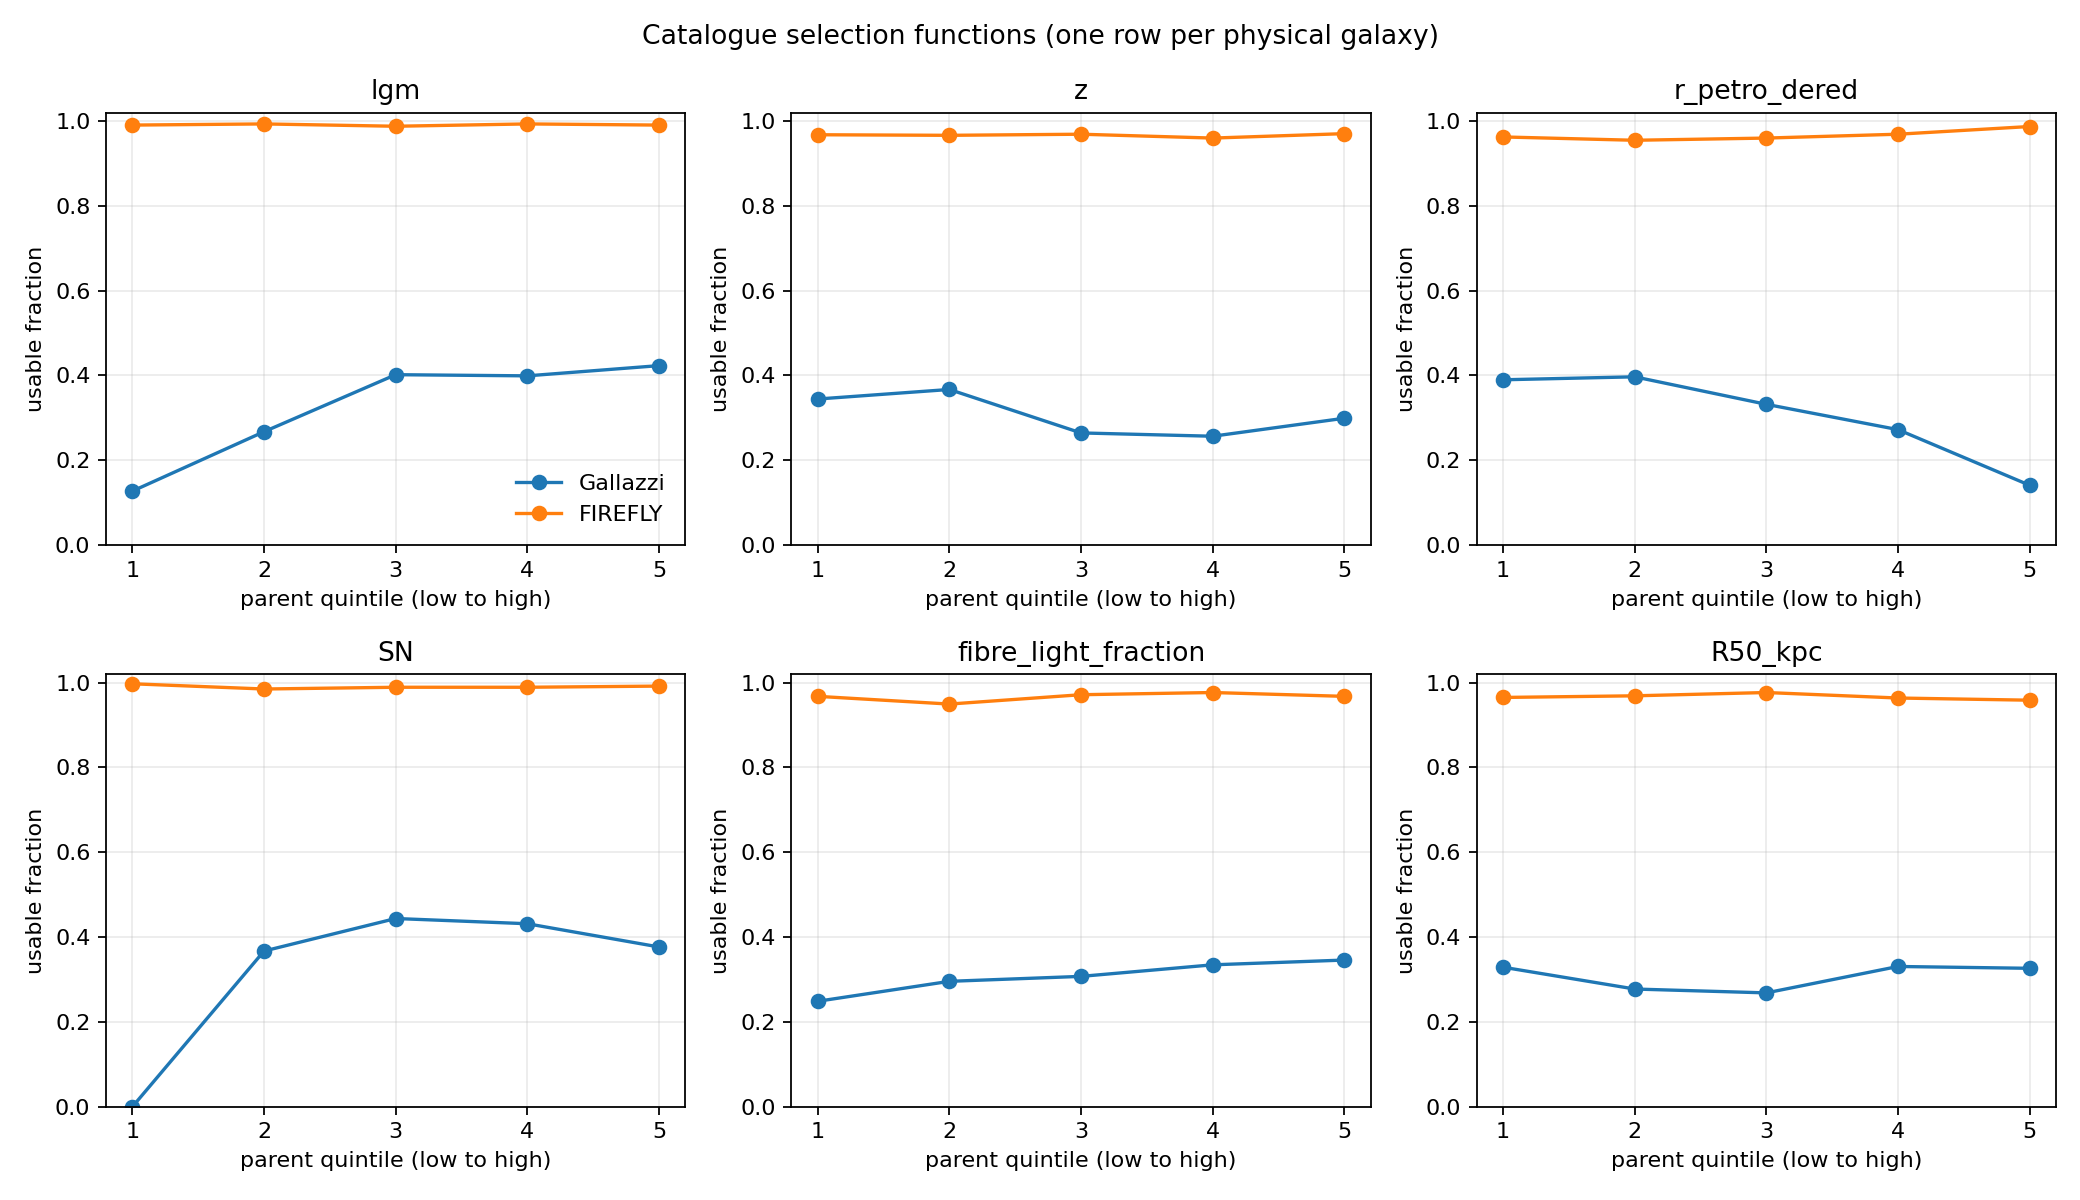

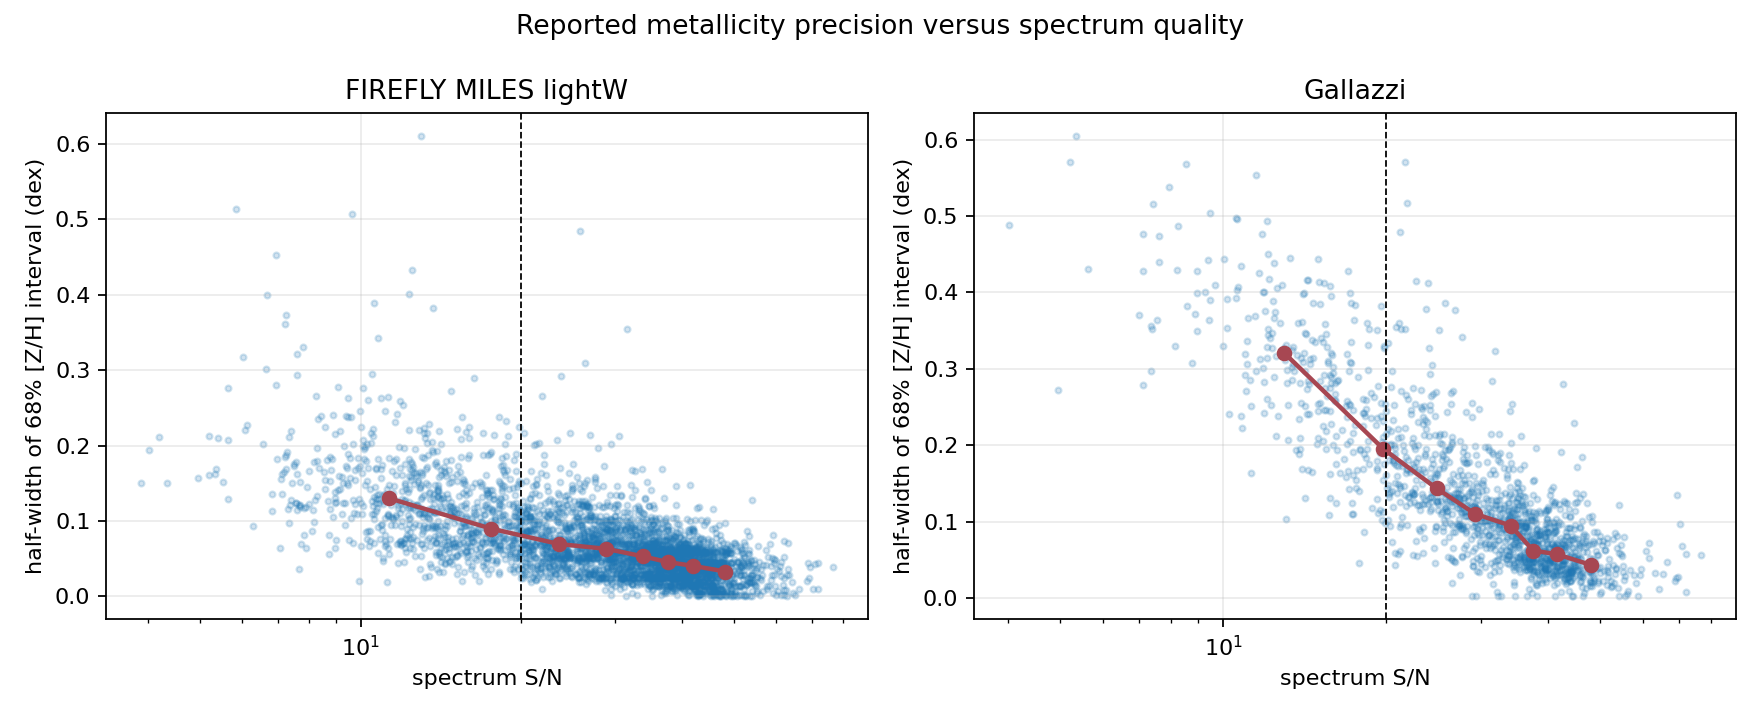

In [4]:
smd = pd.read_csv(HERE / "outputs/zstar/selection_smd.csv")
display(smd.assign(abs_smd=smd.usable_minus_not_smd.abs()).sort_values("abs_smd", ascending=False).head(12))
display(Image(filename=str(HERE / "figures/zstar/selection_functions.png")))
display(Image(filename=str(HERE / "figures/zstar/uncertainty_vs_sn.png")))

## 3. Gallazzi–FIREFLY cross-calibration

The common scale is `[Z/H]`. The primary object-level comparison uses Gallazzi's S/N-qualified sample and FIREFLY MILES light-weighted metallicity. ELODIE and mass-weighted combinations are fixed model-systematic checks rather than candidates selected by environmental effect size.

,comparison,stratum,n,median_offset_dex,robust_scatter_dex,catastrophic_threshold_dex_from_median,catastrophic_n,theil_sen_slope,slope_ci95_lo,slope_ci95_hi
0,Gallazzi minus FIREFLY MILES light-weighted,all overlap (Gallazzi S/N>=20),1164,-0.037030,0.127642,0.5,49.0,NaN,NaN,NaN
1,Gallazzi minus FIREFLY MILES light-weighted,trend versus lgm,1163,NaN,NaN,NaN,NaN,0.094869,0.074216,0.115918
2,Gallazzi minus FIREFLY MILES light-weighted,trend versus z,1164,NaN,NaN,NaN,NaN,1.543490,0.270156,2.832249
3,Gallazzi minus FIREFLY MILES light-weighted,trend versus SN,1164,NaN,NaN,NaN,NaN,0.002640,0.001681,0.003630
4,Gallazzi minus FIREFLY MILES light-weighted,trend versus fibre_light_fraction,1164,NaN,NaN,NaN,NaN,-0.231190,-0.323686,-0.138629
5,Gallazzi minus FIREFLY MILES light-weighted,morphology4=Elliptical,594,-0.042594,0.110883,NaN,NaN,NaN,NaN,NaN
6,Gallazzi minus FIREFLY MILES light-weighted,morphology4=NoGZ,100,-0.045725,0.117036,NaN,NaN,NaN,NaN,NaN
7,Gallazzi minus FIREFLY MILES light-weighted,morphology4=Spiral,431,-0.022104,0.155263,NaN,NaN,NaN,NaN,NaN
8,Gallazzi minus FIREFLY MILES light-weighted,morphology4=Uncertain,39,-0.045165,0.199815,NaN,NaN,NaN,NaN,NaN
9,Gallazzi minus FIREFLY MILES light-weighted,sf_state=NosSFR,9,0.050015,0.082439,NaN,NaN,NaN,NaN,NaN


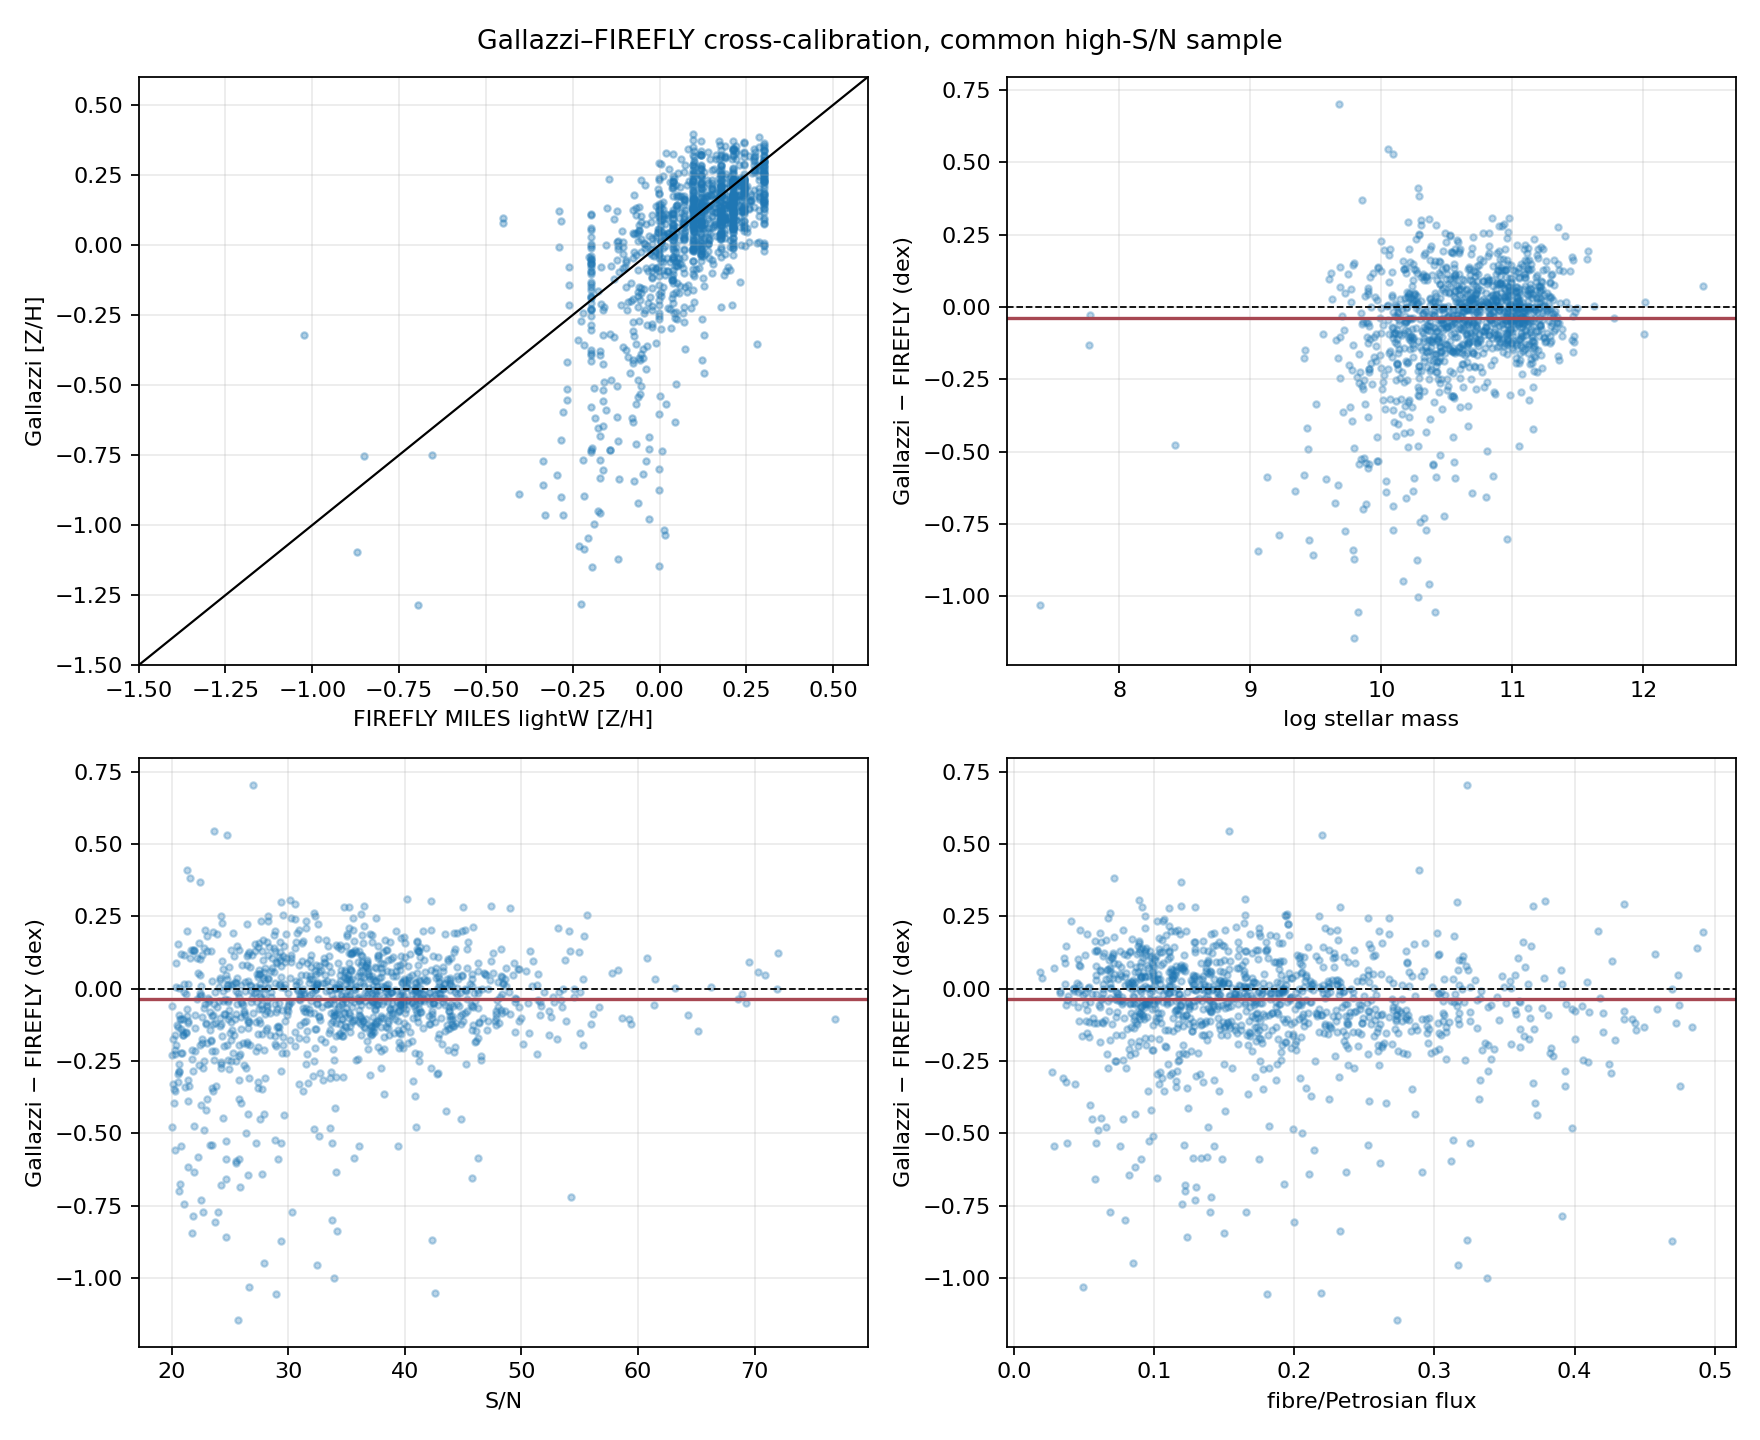

In [5]:
cross = pd.read_csv(HERE / "outputs/zstar/crosscal_summary.csv")
display(cross)
display(Image(filename=str(HERE / "figures/zstar/cross_calibration.png")))

## 4. Mass–metallicity relation and environmental contrasts

The total contrast is `[Z/H] ~ f(log M*) + CG4`. A quadratic is admitted only if five-fold group CV improves Control4C RMSE by at least 2%. Groups are resampled within sample for 1,000 bootstrap replicates; no p-values or model shopping are used.

,role,n_CG4,n_control,degree,beta,cluster_se,standardized_effect,ci68_lo,ci68_hi,ci95_lo,ci95_hi
0,BGG,57,648,1,-0.015102,0.014728,-0.162144,-0.029987,0.000372,-0.044112,0.012083
3,Satellite,176,1978,1,0.002711,0.010695,0.018267,-0.008321,0.013004,-0.019250,0.023113


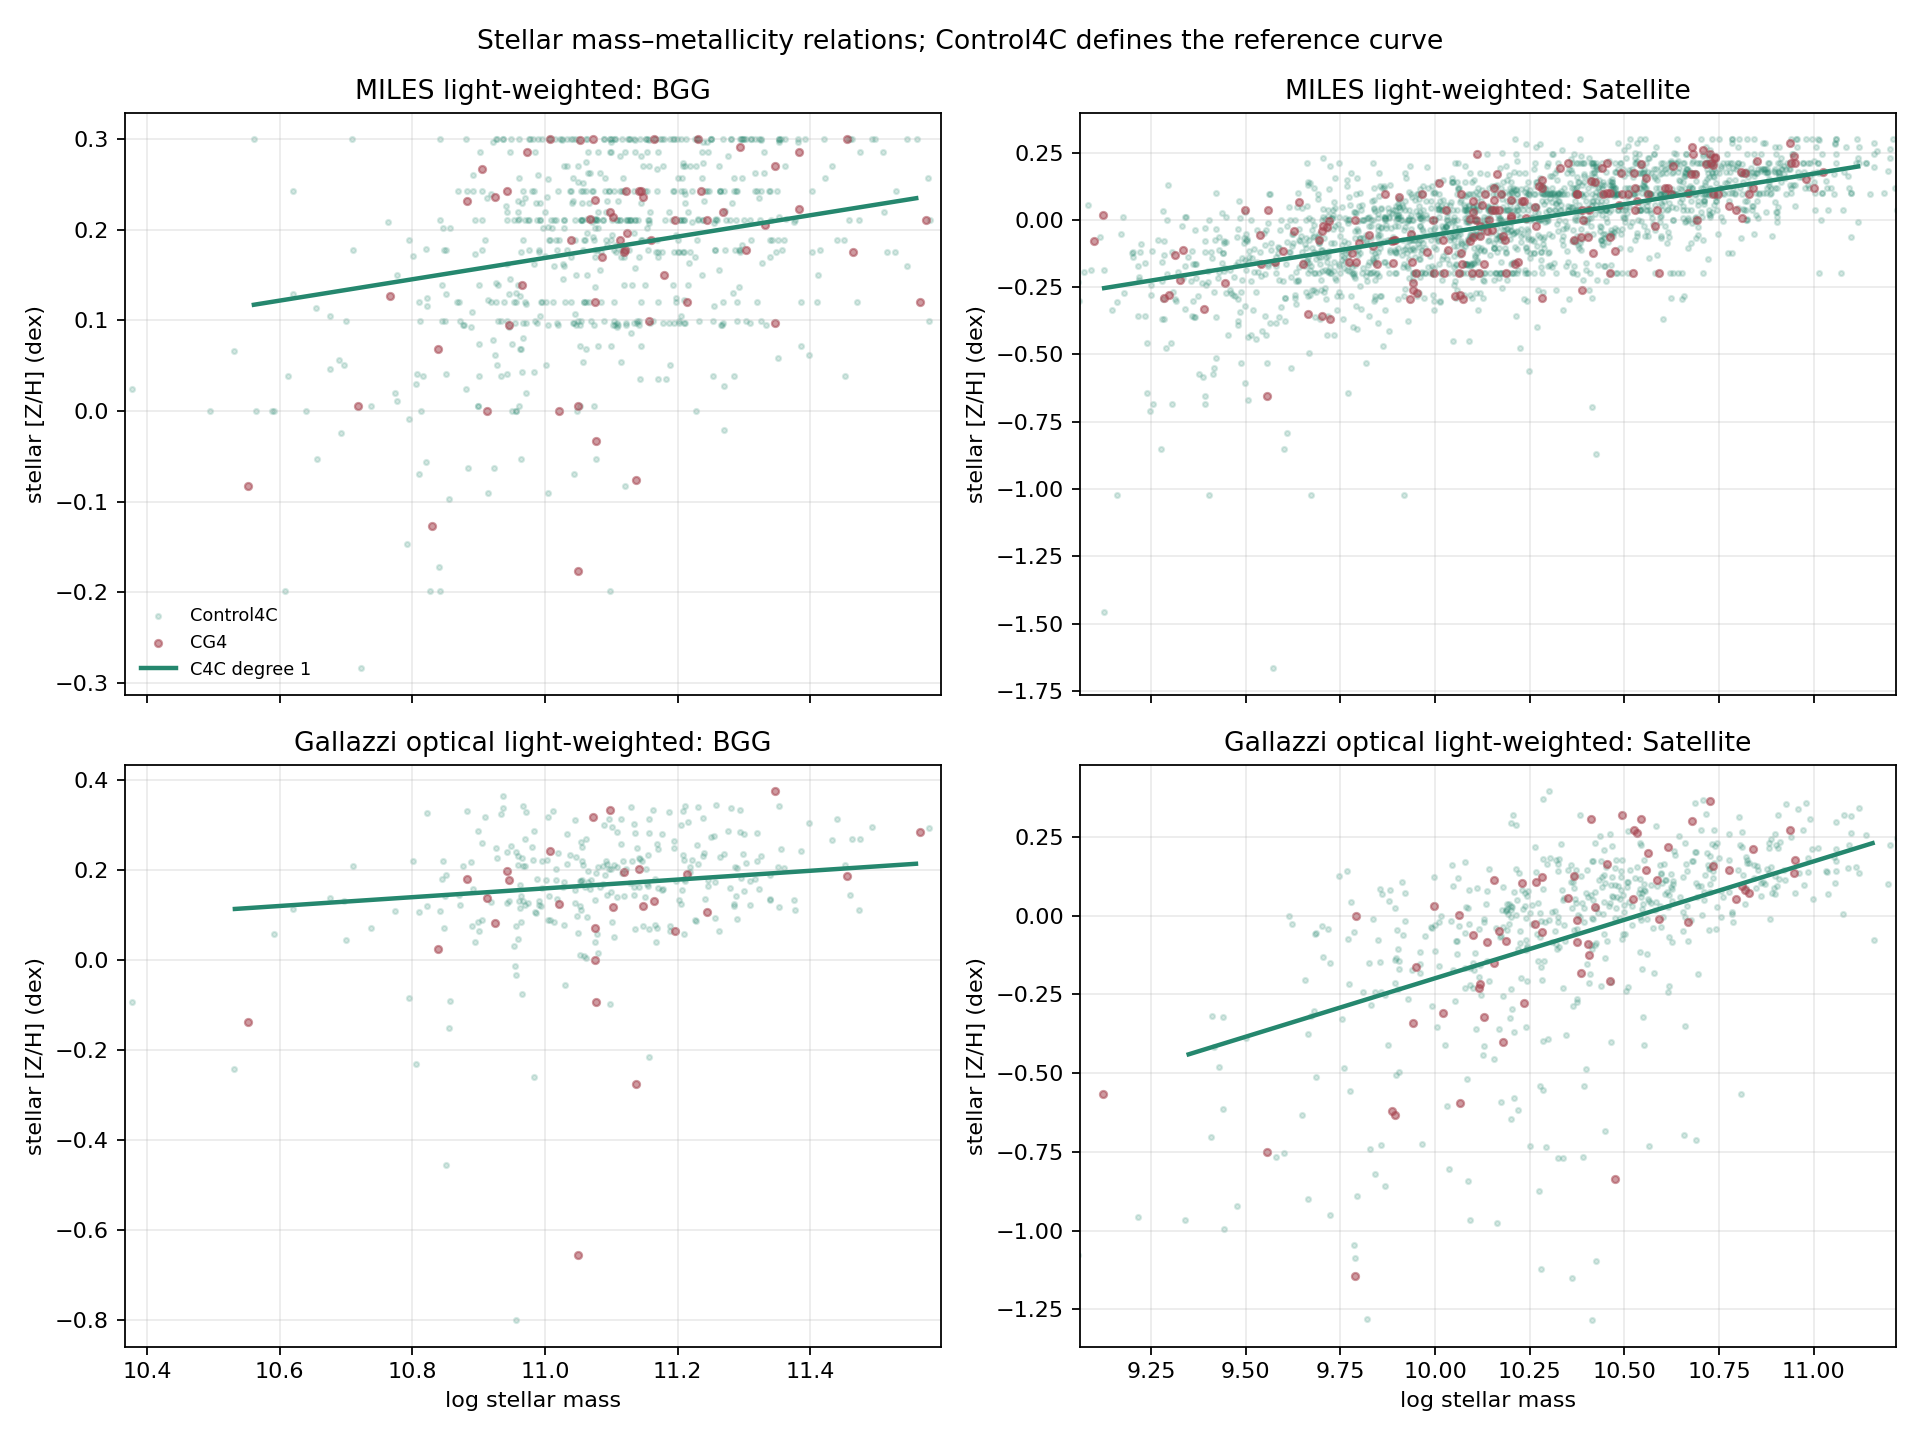

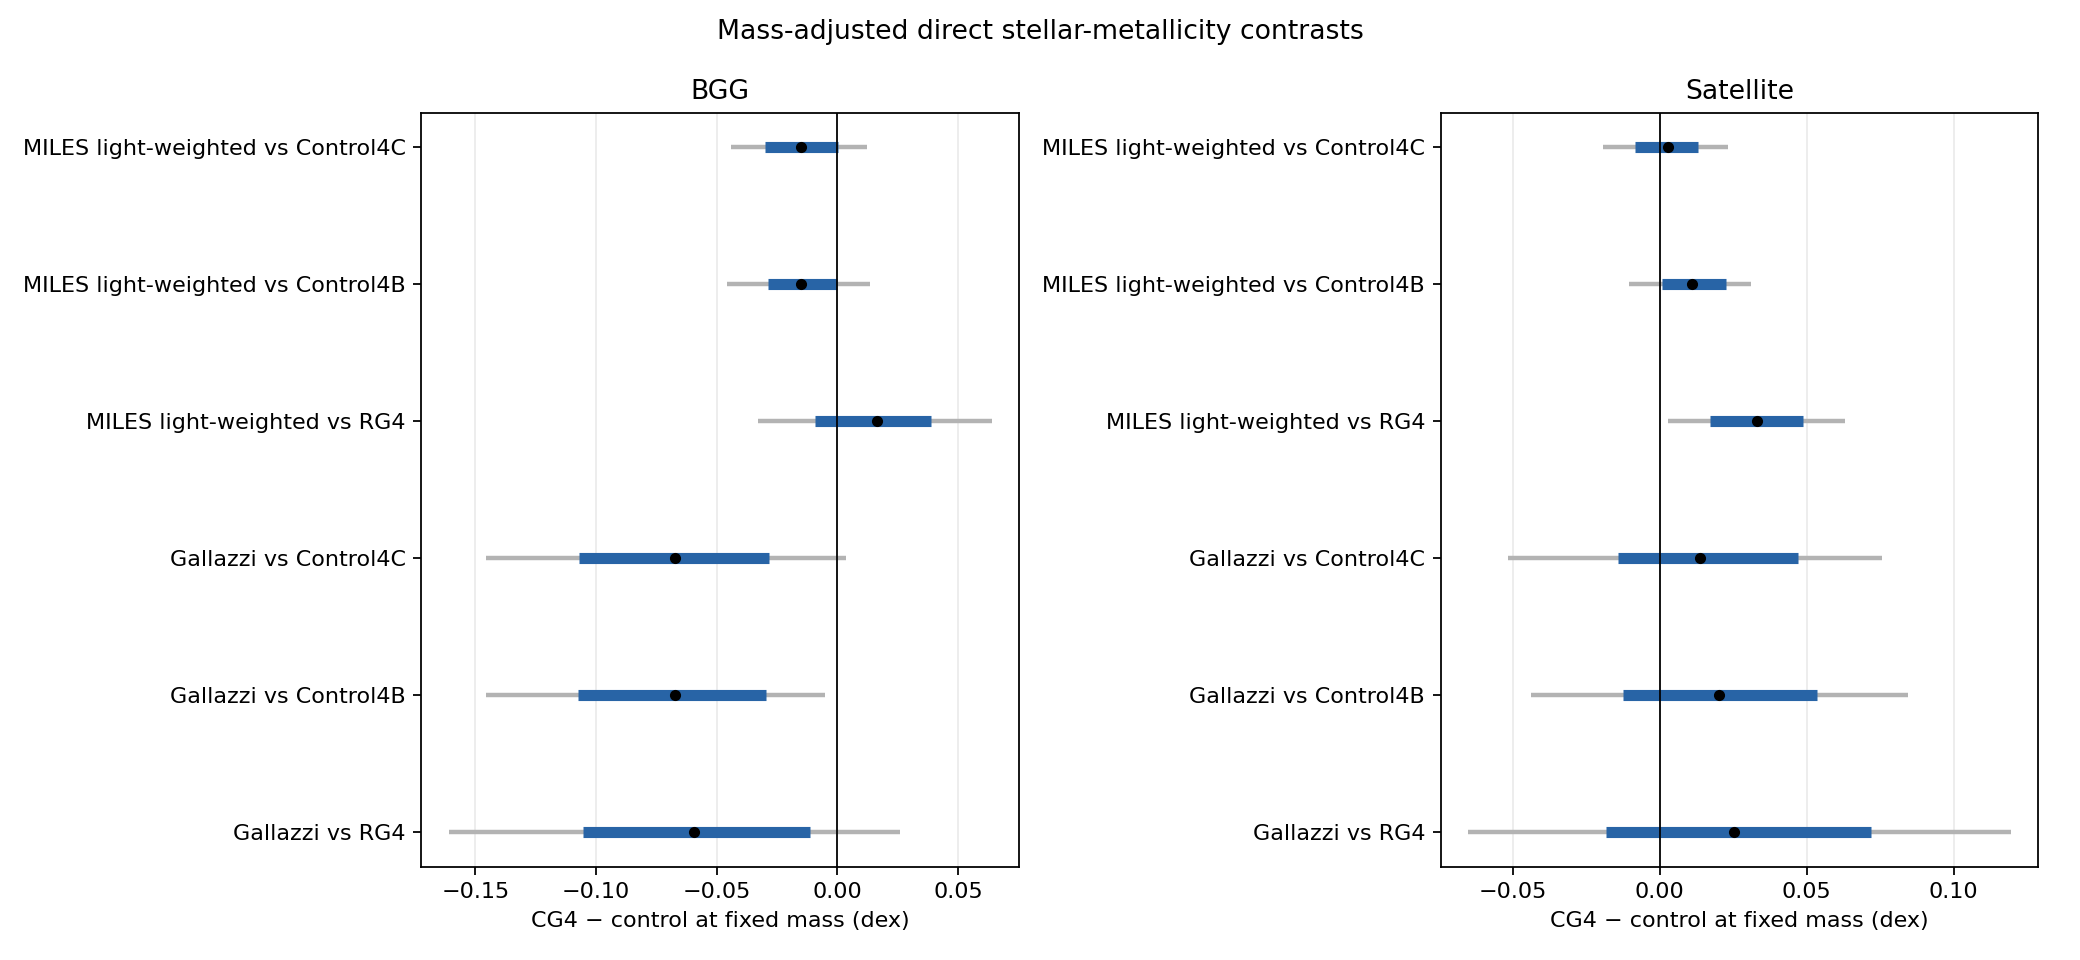

In [6]:
contrasts = pd.read_csv(HERE / "outputs/zstar/zstar_contrasts.csv")
primary = contrasts[(contrasts["product"] == za.PRIMARY) & (contrasts["control"] == "Control4C")]
display(primary[["role", "n_CG4", "n_control", "degree", "beta", "cluster_se", "standardized_effect", "ci68_lo", "ci68_hi", "ci95_lo", "ci95_hi"]])
display(Image(filename=str(HERE / "figures/zstar/mass_metallicity.png")))
display(Image(filename=str(HERE / "figures/zstar/direct_effects.png")))

## 5. Morphology, SF state, and velocity dispersion

The unconditioned mass-adjusted contrast remains primary. Subsets show how the total result decomposes. Sigma is added only alongside mass in early/passive sensitivities and is not treated as a replacement for mass.

,role,subset,n_CG4,n_control,beta,ci95_lo,ci95_hi
0,BGG,total,57,648,-0.015102,-0.044115,0.013079
1,BGG,morphology=Elliptical,36,404,0.005546,-0.018842,0.029848
2,BGG,morphology=Spiral,17,194,-0.043478,-0.106794,0.012806
3,BGG,SF=Quenched,45,532,0.008763,-0.013319,0.027732
4,BGG,SF=Starforming,11,106,-0.082478,-0.146075,-0.023052
5,BGG,Elliptical + sigma,36,404,0.007698,-0.018026,0.030125
6,BGG,Quenched + sigma,45,532,0.006950,-0.012564,0.025403
7,Satellite,total,176,1978,0.002711,-0.017554,0.023587
8,Satellite,morphology=Elliptical,88,704,-0.021298,-0.049559,0.007315
9,Satellite,morphology=Spiral,68,1028,0.018037,-0.006603,0.041869


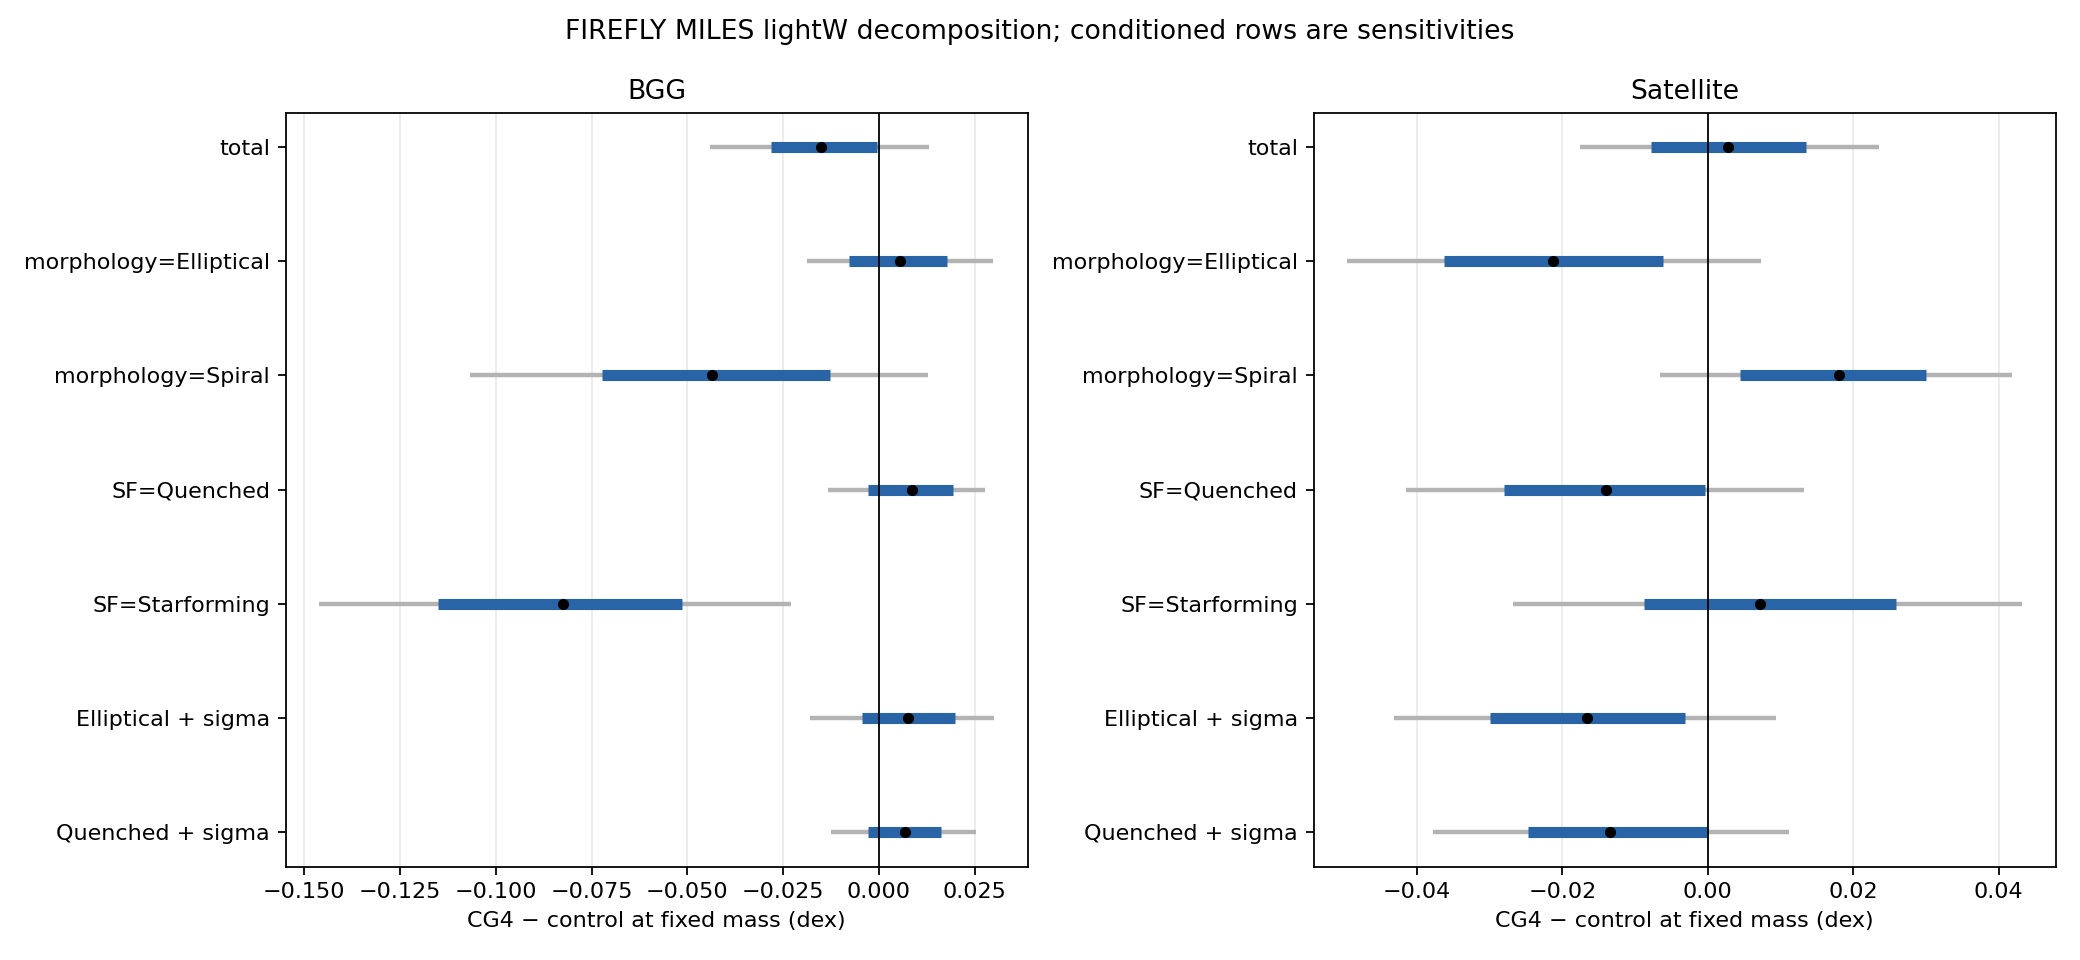

In [7]:
decomp = pd.read_csv(HERE / "outputs/zstar/zstar_decomposition.csv")
display(decomp[decomp["product"] == za.PRIMARY][["role", "subset", "n_CG4", "n_control", "beta", "ci95_lo", "ci95_hi"]])
display(Image(filename=str(HERE / "figures/zstar/decomposition.png")))

## 6. Aperture, redshift, S/N, and model robustness

,role,variant,n_CG4,n_control,beta,ci95_lo,ci95_hi
0,BGG,base usable,57,648,-0.015102,-0.047272,0.014481
1,BGG,metallicity uncertainty <=0.3 dex,57,648,-0.015102,-0.046267,0.014116
2,BGG,S/N>5,57,648,-0.015102,-0.042925,0.012376
3,BGG,S/N>20,56,647,-0.015207,-0.046393,0.013395
4,BGG,legacy RUN2D=26 only,57,648,-0.015102,-0.046325,0.011429
5,BGG,adjust redshift,57,648,-0.011249,-0.038926,0.017933
6,BGG,adjust fibre light fraction,57,648,-0.017457,-0.045144,0.009107
7,BGG,adjust physical fibre radius,57,648,-0.011233,-0.040386,0.016655
8,BGG,adjust galaxy R50,57,648,-0.013063,-0.043992,0.015436
9,BGG,adjust z + fibre fraction + R50,57,648,-0.013057,-0.039571,0.011776


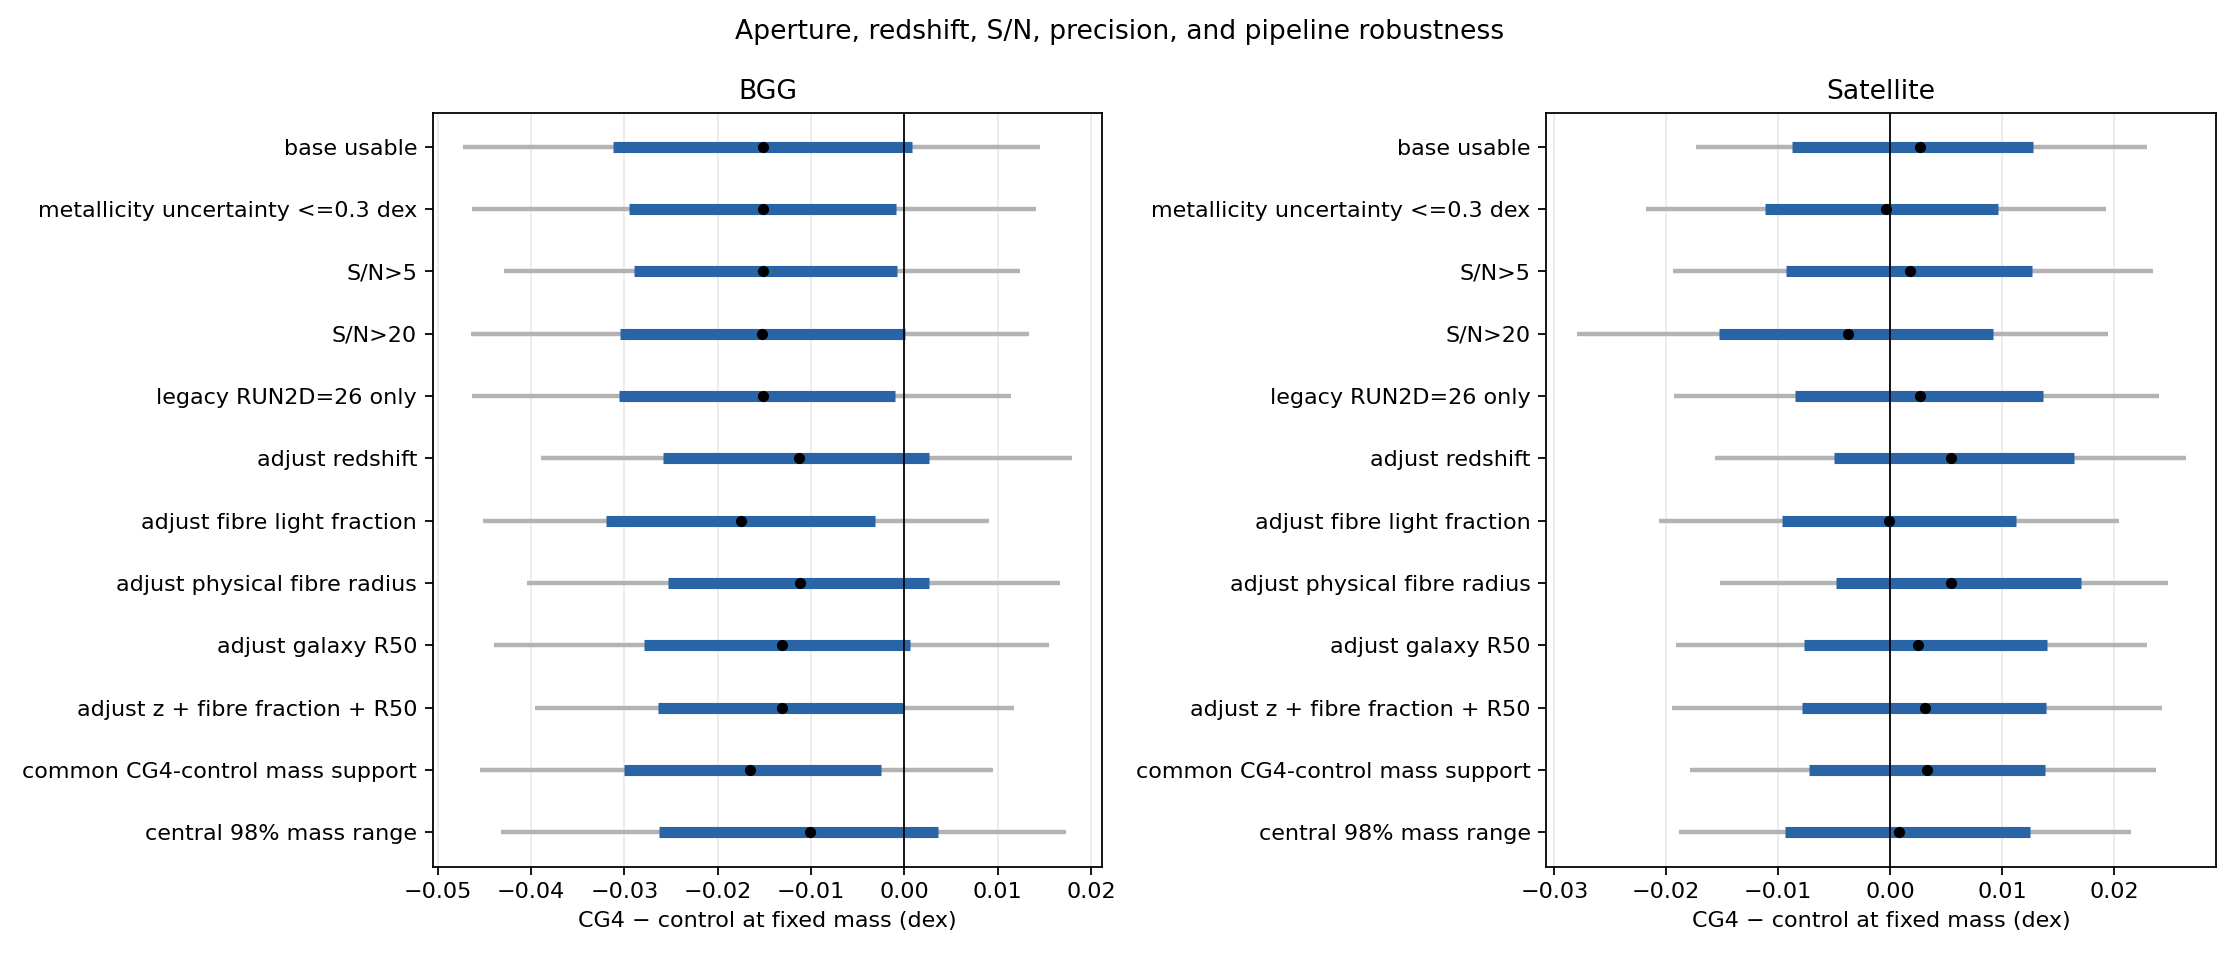

In [8]:
robust = pd.read_csv(HERE / "outputs/zstar/zstar_robustness.csv")
display(robust[["role", "variant", "n_CG4", "n_control", "beta", "ci95_lo", "ci95_hi"]])
display(Image(filename=str(HERE / "figures/zstar/robustness.png")))

## 7. Historical index sensitivity to stellar mass

This is a new sensitivity table; it does not overwrite Claude's historical output. The paired comparison uses identical mass-complete satellite rows under the Claude-like morphology-plus-sigma model and after adding stellar mass.

beta_CG4                                cluster_se  \
specification + stellar mass Claude-like, mass-complete + stellar mass   
index                                                                    
Dn4000              0.003287                   0.007027       0.015117   
Fe5270             -0.016385                  -0.003309       0.047986   
Fe5335             -0.021278                  -0.008290       0.062240   
Hdelta_A           -0.164830                  -0.202941       0.171749   
Mg2                 0.002742                   0.003608       0.002994   
Mgb                 0.029977                   0.043814       0.056695   
[MgFe]'            -0.010497                   0.002376       0.043825   

                                          
specification Claude-like, mass-complete  
index                                     
Dn4000                          0.015194  
Fe5270                          0.048689  
Fe5335                          0.062191  
Hdelta_A                        0.174082  
Mg2                             0.003149  
Mgb                             0.058316  
[MgFe]'                         0.045348

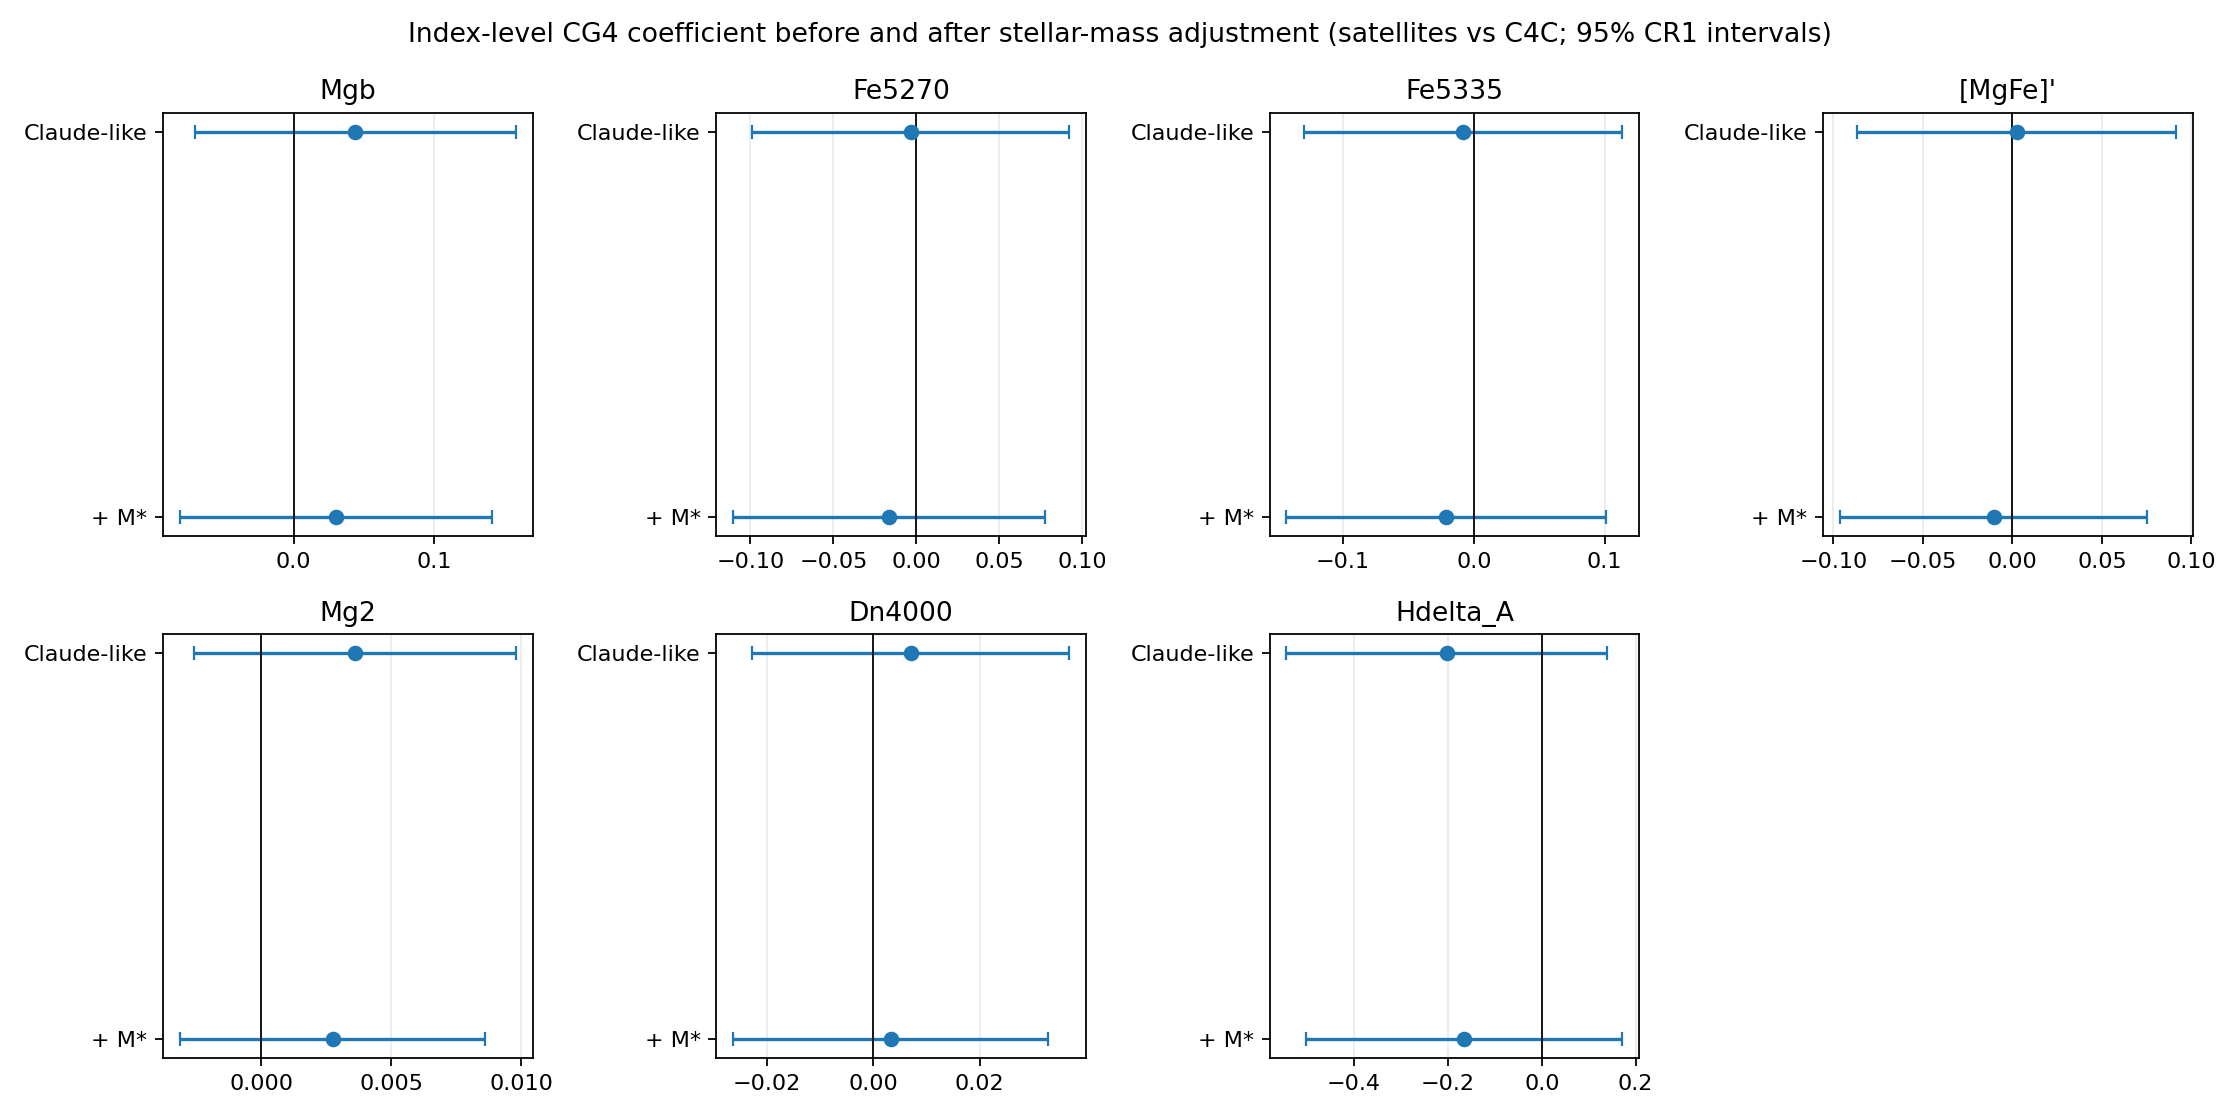

In [9]:
indices = pd.read_csv(HERE / "outputs/zstar/index_mass_sensitivity.csv")
c4c = indices[(indices["control"] == "Control4C") & indices["specification"].isin(["Claude-like, mass-complete", "+ stellar mass"])]
display(c4c.pivot(index="index", columns="specification", values=["beta_CG4", "cluster_se"]))
display(Image(filename=str(HERE / "figures/zstar/index_mass_sensitivity.png")))

## 8. Full interpretation

The generated report contains the complete numerical audit, catalogue documentation, caveats, and file map.

In [10]:
display(Markdown((HERE / "ZSTAR_REPORT.md").read_text()))

# Direct stellar metallicity extension

## Bottom line

This is an exploratory extension of Claude's immutable [index-level feasibility study](REPORT.md), not a replacement for it. FIREFLY provides the decisive coverage advantage and is therefore the primary direct-$Z_\star$ catalogue. After stellar-mass adjustment against the project-defined Control4C analogue, the FIREFLY MILES light-weighted contrast is **+0.003 dex (95% group-bootstrap CI -0.019 to +0.023; N=176+1978) for satellites** and **-0.015 dex (95% group-bootstrap CI -0.044 to +0.012; N=57+648) for BGGs**. The independent Gallazzi estimates are **+0.014 dex (95% group-bootstrap CI -0.052 to +0.076; N=63+553)** and **-0.067 dex (95% group-bootstrap CI -0.146 to +0.004; N=27+283)**, respectively. These are effect estimates with uncertainty, not detections selected by a significance threshold.

The object-level catalogues are not interchangeable: among 1164 common high-S/N objects, Gallazzi minus FIREFLY has median -0.037 dex and robust scatter 0.128 dex. They are nevertheless useful as independent environmental checks because the comparison uses the same product and model within each catalogue.

## Acquisition and definitions

- Spectrum identity is plate–MJD–fibre throughout. FIREFLY `SPECOBJID` is deliberately ignored because the DR16 VAC documentation warns that it is corrupted.
- The combined SDSS/eBOSS DR16 VAC is the published product. Its legacy SDSS `RUN2D=26` spectra were fit with FIREFLY v1.1.0; the BOSS/eBOSS `RUN2D=v5_13_0` spectra used v1.1.1. The matched split is 3645 + 190 = 3835.
- Gallazzi DR4 stores $\log_{10} Z$ for absolute metal mass fraction $Z$. Following its catalogue page, this analysis subtracts $\log_{10}(0.02)$ to obtain $[Z/H]=\log_{10}(Z/Z_\odot)$. The model grid uses BC03/STELIB and interprets the single-$Z$ model as optical-light-weighted metallicity.
- FIREFLY quantities such as `Chabrier_MILES_metallicity_lightW` are linear solar metallicities ($Z/Z_\odot$), so they are transformed with $\log_{10}$. MILES light-weighted is primary: it matches Gallazzi's optical weighting most closely and MILES has broader wavelength coverage than ELODIE. ELODIE and both mass-weighted products are model-systematic checks fixed in advance.
- Gallazzi `-99` and FIREFLY `-9999` are invalid. Physical positivity, ordered 68% bounds, `CLASS_NOQSO=GALAXY`, and $Z>Z_{err}>0$ are enforced before use.
- Gallazzi's published S/N≥20 reliability result defines its usable sample. FIREFLY receives no automatic S/N=20 cut; valid galaxy/redshift/posterior rows are primary, with uncertainty≤0.3 dex and S/N cuts shown only as sensitivities.

Authoritative local snapshots: [Gallazzi catalogue documentation](work/catalogues/gallazzi/stellarmet.html), [Gallazzi et al. 2005](work/catalogues/gallazzi/Gallazzi2005_arxiv.pdf), [FIREFLY DR16 VAC](work/catalogues/firefly/sdss_dr16_firefly.html), [FIREFLY data model](work/catalogues/firefly/sdss_eboss_firefly-DR16_datamodel.html), and [Comparat et al. 2019](work/catalogues/firefly/Comparat2019_arxiv.pdf).

## Coverage audit

| catalogue | sample | role | parent_n | match_n | valid_n | usable_n | retained_% | median_z | median_logmstar | median_SN | median_logz_unc_dex |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Gallazzi DR4 | CG4 | BGG | 62 | 30 | 27 | 27 | 43.5 | 0.0367 | 11.08 | 41.0 | 0.069 |
| Gallazzi DR4 | CG4 | Satellite | 186 | 99 | 76 | 63 | 33.9 | 0.0370 | 10.37 | 28.8 | 0.106 |
| Gallazzi DR4 | RG4 | BGG | 56 | 31 | 30 | 30 | 53.6 | 0.0389 | 10.99 | 38.4 | 0.077 |
| Gallazzi DR4 | RG4 | Satellite | 168 | 93 | 73 | 43 | 25.6 | 0.0373 | 10.43 | 26.4 | 0.128 |
| Gallazzi DR4 | Control4B | BGG | 698 | 296 | 283 | 282 | 40.4 | 0.0342 | 11.09 | 41.5 | 0.059 |
| Gallazzi DR4 | Control4B | Satellite | 2094 | 904 | 799 | 637 | 30.4 | 0.0334 | 10.60 | 34.0 | 0.096 |
| Gallazzi DR4 | Control4C | BGG | 703 | 297 | 284 | 283 | 40.3 | 0.0343 | 11.09 | 41.5 | 0.059 |
| Gallazzi DR4 | Control4C | Satellite | 2109 | 907 | 774 | 553 | 26.2 | 0.0334 | 10.40 | 30.2 | 0.110 |
| FIREFLY DR16 MILES light-weighted | CG4 | BGG | 62 | 61 | 60 | 60 | 96.8 | 0.0365 | 11.12 | 41.1 | 0.035 |
| FIREFLY DR16 MILES light-weighted | CG4 | Satellite | 186 | 185 | 180 | 180 | 96.8 | 0.0366 | 10.18 | 25.8 | 0.069 |
| FIREFLY DR16 MILES light-weighted | RG4 | BGG | 56 | 56 | 55 | 55 | 98.2 | 0.0403 | 10.98 | 38.3 | 0.049 |
| FIREFLY DR16 MILES light-weighted | RG4 | Satellite | 168 | 168 | 167 | 167 | 99.4 | 0.0403 | 10.07 | 18.9 | 0.087 |
| FIREFLY DR16 MILES light-weighted | Control4B | BGG | 698 | 695 | 674 | 674 | 96.6 | 0.0353 | 11.10 | 42.3 | 0.040 |
| FIREFLY DR16 MILES light-weighted | Control4B | Satellite | 2094 | 2082 | 2031 | 2031 | 97.0 | 0.0352 | 10.47 | 30.2 | 0.060 |
| FIREFLY DR16 MILES light-weighted | Control4C | BGG | 703 | 700 | 678 | 678 | 96.4 | 0.0353 | 11.10 | 42.3 | 0.040 |
| FIREFLY DR16 MILES light-weighted | Control4C | Satellite | 2109 | 2097 | 2042 | 2042 | 96.8 | 0.0353 | 10.20 | 25.5 | 0.069 |

`match_n` is identity coverage; `valid_n` removes sentinels/non-physical posteriors; `usable_n` additionally applies the catalogue-specific rules above. Parent N is never silently redefined.

The largest continuous usable-versus-not-usable imbalances (standardised mean difference; positive means larger among usable objects) are:

| catalogue | variable | usable_minus_not_smd | usable_median | not_usable_median |
| --- | --- | --- | --- | --- |
| Gallazzi DR4 | SN | +0.61 | 35.087 | 28.368 |
| Gallazzi DR4 | lgm | +0.50 | 10.666 | 10.370 |
| Gallazzi DR4 | r_petro_dered | -0.45 | 14.645 | 15.202 |
| FIREFLY DR16 MILES light-weighted | r_petro_dered | +0.26 | 15.018 | 14.695 |
| FIREFLY DR16 MILES light-weighted | R50_kpc | -0.17 | 3.607 | 3.815 |
| FIREFLY DR16 MILES light-weighted | lgm | +0.13 | 10.482 | 10.571 |

Gallazzi retention is materially composition-dependent: 39.3% for ellipticals versus 25.2% for spirals, and 39.4% for quenched versus 22.3% for star-forming galaxies. FIREFLY is 99.2% complete for ellipticals and 99.3% for spirals, but falls to 75.6% for objects without a GZ class and 61.4% without a parent-catalogue SF state. Full rates are in `outputs/zstar/selection_rates.csv`; the non-parametric quintile curves in `figures/zstar/selection_functions.png` expose mass, redshift, magnitude, S/N, fibre-fraction, and size dependence without treating duplicated control labels as independent galaxies.

## Cross-calibration

| comparison | stratum | n | median_offset_dex | robust_scatter_dex | theil_sen_slope | slope_ci95_lo | slope_ci95_hi | catastrophic_n |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Gallazzi minus FIREFLY MILES light-weighted | all overlap (Gallazzi S/N>=20) | 1164 | -0.037 | 0.128 | – | – | – | 49.0 |
| Gallazzi minus FIREFLY MILES light-weighted | trend versus lgm | 1163 | – | – | +0.095 | +0.074 | +0.116 | – |
| Gallazzi minus FIREFLY MILES light-weighted | trend versus z | 1164 | – | – | +1.543 | +0.270 | +2.832 | – |
| Gallazzi minus FIREFLY MILES light-weighted | trend versus SN | 1164 | – | – | +0.003 | +0.002 | +0.004 | – |
| Gallazzi minus FIREFLY MILES light-weighted | trend versus fibre_light_fraction | 1164 | – | – | -0.231 | -0.324 | -0.139 | – |
| Gallazzi minus FIREFLY MILES light-weighted | morphology4=Elliptical | 594 | -0.043 | 0.111 | – | – | – | – |
| Gallazzi minus FIREFLY MILES light-weighted | morphology4=NoGZ | 100 | -0.046 | 0.117 | – | – | – | – |
| Gallazzi minus FIREFLY MILES light-weighted | morphology4=Spiral | 431 | -0.022 | 0.155 | – | – | – | – |
| Gallazzi minus FIREFLY MILES light-weighted | morphology4=Uncertain | 39 | -0.045 | 0.200 | – | – | – | – |
| Gallazzi minus FIREFLY MILES light-weighted | sf_state=NosSFR | 9 | +0.050 | 0.082 | – | – | – | – |
| Gallazzi minus FIREFLY MILES light-weighted | sf_state=Quenched | 835 | -0.032 | 0.109 | – | – | – | – |
| Gallazzi minus FIREFLY MILES light-weighted | sf_state=Starforming | 320 | -0.058 | 0.247 | – | – | – | – |
| MILES lw minus ELODIE lw | all | 3728 | +0.086 | 0.095 | – | – | – | – |
| MILES lw minus ELODIE lw | RUN2D=26 | 3615 | +0.084 | 0.093 | – | – | – | – |
| MILES lw minus ELODIE lw | RUN2D=v5_13_0 | 113 | +0.442 | 0.446 | – | – | – | – |
| MILES mw minus MILES lw | all | 3728 | -0.056 | 0.102 | – | – | – | – |
| MILES mw minus MILES lw | RUN2D=26 | 3615 | -0.054 | 0.099 | – | – | – | – |
| MILES mw minus MILES lw | RUN2D=v5_13_0 | 113 | -0.126 | 0.180 | – | – | – | – |
| ELODIE mw minus ELODIE lw | all | 3728 | -0.009 | 0.060 | – | – | – | – |
| ELODIE mw minus ELODIE lw | RUN2D=26 | 3615 | -0.008 | 0.058 | – | – | – | – |
| ELODIE mw minus ELODIE lw | RUN2D=v5_13_0 | 113 | -0.400 | 0.593 | – | – | – | – |

A catastrophic disagreement is defined before inspection as an absolute residual from the median larger than max(0.5 dex, three robust scatters); 49 objects meet it and are listed in `crosscal_outliers.csv`. The MILES/ELODIE and light-/mass-weighted offsets show that stellar-library and weighting choice are material model systematics; they are not averaged away.

## Mass-adjusted environmental contrasts

The model is $[Z/H]=f(\log M_\star)+\beta_{CG}I(CG4)+\epsilon$, fit separately to satellites and BGGs. A linear Control4C relation is the default; a quadratic is used only when five-fold group CV reduces RMSE by at least 2%. Intervals come from 1,000 cluster-pairs bootstrap replicates, resampled within sample; the reported CR1 SE and standardised effect are retained in the CSV.

| product | role | control | degree | estimate |
| --- | --- | --- | --- | --- |
| FIREFLY MILES light-weighted | BGG | Control4C | 1 | -0.015 dex (95% group-bootstrap CI -0.044 to +0.012; N=57+648) |
| FIREFLY MILES light-weighted | BGG | Control4B | 1 | -0.015 dex (95% group-bootstrap CI -0.046 to +0.013; N=57+644) |
| FIREFLY MILES light-weighted | BGG | RG4 | 1 | +0.016 dex (95% group-bootstrap CI -0.033 to +0.064; N=57+53) |
| FIREFLY MILES light-weighted | Satellite | Control4C | 1 | +0.003 dex (95% group-bootstrap CI -0.019 to +0.023; N=176+1978) |
| FIREFLY MILES light-weighted | Satellite | Control4B | 1 | +0.011 dex (95% group-bootstrap CI -0.011 to +0.031; N=176+1976) |
| FIREFLY MILES light-weighted | Satellite | RG4 | 1 | +0.033 dex (95% group-bootstrap CI +0.003 to +0.063; N=176+166) |
| Gallazzi optical light-weighted | BGG | Control4C | 1 | -0.067 dex (95% group-bootstrap CI -0.146 to +0.004; N=27+283) |
| Gallazzi optical light-weighted | BGG | Control4B | 1 | -0.067 dex (95% group-bootstrap CI -0.146 to -0.005; N=27+282) |
| Gallazzi optical light-weighted | BGG | RG4 | 1 | -0.059 dex (95% group-bootstrap CI -0.161 to +0.026; N=27+30) |
| Gallazzi optical light-weighted | Satellite | Control4C | 1 | +0.014 dex (95% group-bootstrap CI -0.052 to +0.076; N=63+553) |
| Gallazzi optical light-weighted | Satellite | Control4B | 1 | +0.020 dex (95% group-bootstrap CI -0.044 to +0.084; N=63+636) |
| Gallazzi optical light-weighted | Satellite | RG4 | 2 | +0.025 dex (95% group-bootstrap CI -0.065 to +0.120; N=63+43) |

Control4C is primary because the repository defines it as the BGG plus the three nearest projected eligible companions—the closest ordinary-group analogue to a compact core. Control4B and RG4 answer secondary bright-member and equal-membership questions and are shown without pooling duplicated physical control groups.

The pre-fixed FIREFLY model-systematic checks against Control4C are:

| product | role | degree | estimate |
| --- | --- | --- | --- |
| FIREFLY MILES light-weighted | BGG | 1 | -0.015 dex (95% group-bootstrap CI -0.044 to +0.012; N=57+648) |
| FIREFLY MILES light-weighted | Satellite | 1 | +0.003 dex (95% group-bootstrap CI -0.019 to +0.023; N=176+1978) |
| FIREFLY ELODIE light-weighted | BGG | 2 | -0.015 dex (95% group-bootstrap CI -0.041 to +0.007; N=57+648) |
| FIREFLY ELODIE light-weighted | Satellite | 1 | +0.003 dex (95% group-bootstrap CI -0.016 to +0.020; N=176+1978) |
| FIREFLY MILES mass-weighted | BGG | 1 | -0.021 dex (95% group-bootstrap CI -0.068 to +0.018; N=57+648) |
| FIREFLY MILES mass-weighted | Satellite | 1 | +0.017 dex (95% group-bootstrap CI -0.030 to +0.062; N=176+1978) |
| FIREFLY ELODIE mass-weighted | BGG | 1 | -0.022 dex (95% group-bootstrap CI -0.051 to +0.007; N=57+648) |
| FIREFLY ELODIE mass-weighted | Satellite | 1 | +0.023 dex (95% group-bootstrap CI -0.006 to +0.051; N=176+1978) |

Their intervals overlap the primary result; the mass-weighted satellite point estimates are somewhat more positive but less precise. This is reported as model dependence, not a preferred effect.

## Morphology and star-formation decomposition

The first row for each role is the total mass-adjusted contrast. The conditioned rows describe where the total signal sits; they are not automatically more causal, because morphology and SF state may be environmental outcomes. Sigma enters only alongside stellar mass in the early/passive sensitivity rows.

| role | subset | degree | estimate |
| --- | --- | --- | --- |
| BGG | total | 1 | -0.015 dex (95% group-bootstrap CI -0.044 to +0.013; N=57+648) |
| BGG | morphology=Elliptical | 1 | +0.006 dex (95% group-bootstrap CI -0.019 to +0.030; N=36+404) |
| BGG | morphology=Spiral | 1 | -0.043 dex (95% group-bootstrap CI -0.107 to +0.013; N=17+194) |
| BGG | SF=Quenched | 1 | +0.009 dex (95% group-bootstrap CI -0.013 to +0.028; N=45+532) |
| BGG | SF=Starforming | 2 | -0.082 dex (95% group-bootstrap CI -0.146 to -0.023; N=11+106) |
| BGG | Elliptical + sigma | 1 | +0.008 dex (95% group-bootstrap CI -0.018 to +0.030; N=36+404) |
| BGG | Quenched + sigma | 1 | +0.007 dex (95% group-bootstrap CI -0.013 to +0.025; N=45+532) |
| Satellite | total | 1 | +0.003 dex (95% group-bootstrap CI -0.018 to +0.024; N=176+1978) |
| Satellite | morphology=Elliptical | 1 | -0.021 dex (95% group-bootstrap CI -0.050 to +0.007; N=88+704) |
| Satellite | morphology=Spiral | 1 | +0.018 dex (95% group-bootstrap CI -0.007 to +0.042; N=68+1028) |
| Satellite | SF=Quenched | 1 | -0.014 dex (95% group-bootstrap CI -0.041 to +0.013; N=101+1013) |
| Satellite | SF=Starforming | 1 | +0.007 dex (95% group-bootstrap CI -0.027 to +0.043; N=72+948) |
| Satellite | Elliptical + sigma | 1 | -0.017 dex (95% group-bootstrap CI -0.043 to +0.009; N=87+701) |
| Satellite | Quenched + sigma | 1 | -0.014 dex (95% group-bootstrap CI -0.038 to +0.011; N=100+1009) |

The star-forming BGG row is the one conditioned estimate whose 95% interval excludes zero, but it contains only 11 CG4 BGGs, was inspected within a hierarchy of exploratory subsets, and is not supported by the total or quenched BGG contrasts. It is a follow-up lead, not standalone evidence.


## Aperture, redshift, S/N, and model robustness

| role | beta_min | beta_max | ci95_min | ci95_max |
| --- | --- | --- | --- | --- |
| BGG | -0.017 | -0.010 | -0.047 | +0.018 |
| Satellite | -0.004 | +0.005 | -0.028 | +0.026 |

The full variant-by-variant table is `zstar_robustness.csv`, including common CG4–control mass support and central-98%-mass checks. Fibre flux fraction is computed exactly as $10^{-0.4(m_{fiber,r}-m_{Petro,r})}$; physical fibre radius is 1.5 arcsec times the existing Planck15 scale; galaxy size uses Simard circularised R50 with Petrosian R50 fallback. The base FIREFLY result is not inverse-variance weighted, preventing formally tiny catalogue errors or zero-width grid posteriors from dominating. The MZR figure shows the central 99% mass span for legibility; fits use the full stated samples.

## Claude index sensitivity: adding stellar mass

The historical files are untouched. To isolate mass omission, the fair comparison below uses exactly the same mass-complete satellite rows under both specifications. The Claude-like model is index ~ CG4 + broad morphology + log sigma + (log sigma)^2; the second adds log stellar mass.

| index | Claude-like, mass-complete | + stellar mass | shift_after_mass |
| --- | --- | --- | --- |
| Dn4000 | +0.007 | +0.003 | -0.004 |
| Fe5270 | -0.003 | -0.016 | -0.013 |
| Fe5335 | -0.008 | -0.021 | -0.013 |
| Hdelta_A | -0.203 | -0.165 | +0.038 |
| Mg2 | +0.004 | +0.003 | -0.001 |
| Mgb | +0.044 | +0.030 | -0.014 |
| [MgFe]' | +0.002 | -0.010 | -0.013 |

These indices remain age/abundance-sensitive observables, not direct metallicity estimates. The table quantifies specification sensitivity and does not retroactively promote any index contrast to a $Z_\star$ measurement.

## Figures and reproducibility

- `coverage.png`: eight requested sample/role strata for both catalogues.
- `selection_functions.png` and `uncertainty_vs_sn.png`: availability and quality diagnostics.
- `cross_calibration.png`: object-level pipeline comparison.
- `mass_metallicity.png`: Control4C reference MZR for satellites and BGGs.
- `direct_effects.png`, `decomposition.png`, and `robustness.png`: 68%/95% bootstrap intervals.
- `index_mass_sensitivity.png`: historical-index coefficient shift after adding mass.

Run `zstar_fetch.py` (idempotent; existing downloads/query caches are reused), then `zstar_analysis.py`, then `build_zstar_notebook.py`. The notebook reads the generated products and can execute without network acquisition. All paths and outputs remain inside `exploration/metallicity/`.

## Limits

This is a targeted feasibility extension, not a preregistered confirmatory test. Catalogue availability is selection-dependent, fibre spectra probe galaxy centres, Gallazzi and FIREFLY have different SSP machinery and weighting conventions, FIREFLY model grids can yield boundary/zero-width intervals, and repeated ordinary-group labels are never valid independent replicates. Reported comparisons are conditional on the parent catalogue, chosen spectra, available stellar masses, and the stated quality rules.
